**Langkah 0: Menyiapkan Dataset CSV** *(Jalankan Sekali)*

In [4]:
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris


**A. Membangun Struktur Direktori HDFS** *(bobot 15%)*

In [2]:
# Ubah username sesuai dengan username sistem (misal: 'mahasiswa', 'aramsamsam', atau 'nama lengkap')
username = "Pardede_Putra_Anjasmara" 

# Buat direktori 'raw' dan 'processed'
!hdfs dfs -mkdir -p /user/{username}/ecommerce/raw
!hdfs dfs -mkdir -p /user/{username}/ecommerce/processed

# Tampilkan struktur direktori
!hdfs dfs -ls -R /user/{username}/ecommerce

drwxr-xr-x   - aramsamsam supergroup          0 2026-09-11 11:14 /user/Pardede_Putra_Anjasmara/ecommerce/processed
drwxr-xr-x   - aramsamsam supergroup          0 2026-09-11 11:14 /user/Pardede_Putra_Anjasmara/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS** *(bobot 15%)*

In [5]:
# Upload 3 file CSV ke folder 'raw' HDFS
!hdfs dfs -put transaksi_magelang.csv /user/{username}/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/{username}/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/{username}/ecommerce/raw/

# Verifikasi isi direktori raw beserta ukuran file
!hdfs dfs -ls -h /user/{username}/ecommerce/raw

Found 3 items
-rw-r--r--   1 aramsamsam supergroup     12.0 K 2026-09-11 11:19 /user/Pardede_Putra_Anjasmara/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 aramsamsam supergroup     11.9 K 2026-09-11 11:19 /user/Pardede_Putra_Anjasmara/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 aramsamsam supergroup     12.4 K 2026-09-11 11:19 /user/Pardede_Putra_Anjasmara/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS** *(bobot 25%)*

In [6]:
import subprocess
import io
import pandas as pd

kota_list = ["magelang", "yogyakarta", "semarang"]
df_list = []

# Membaca ketiga file langsung dari HDFS menggunakan perintah 'hdfs dfs -cat'
for kota in kota_list:
    hdfs_path = f"/user/{username}/ecommerce/raw/transaksi_{kota}.csv"
    csv_data = subprocess.check_output(["hdfs", "dfs", "-cat", hdfs_path]).decode("utf-8")
    df_temp = pd.read_csv(io.StringIO(csv_data))
    df_list.append(df_temp)

# Penggabungan DataFrame
df_gabungan = pd.concat(df_list, ignore_index=True)

# Verifikasi jumlah transaksi per kota
print("=== Jumlah Transaksi per Kota ===")
print(df_gabungan["kota"].value_counts())
print("\nTotal Ukuran Data Gabungan:", df_gabungan.shape)

df_gabungan.head()

=== Jumlah Transaksi per Kota ===
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

Total Ukuran Data Gabungan: (600, 7)


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


**D. Mengolah dan Download Hasil ke Direktori `processed`** *(bobot 25%)*

In [7]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

# 2. Membuat tabel ringkasan per kota dan per kategori
df_ringkasan = df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

# 3. Menyimpan kedua hasil ke disk lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

# 4. Unggah kedua file ke folder 'processed' di HDFS
!hdfs dfs -put data_gabungan_bersih.csv /user/{username}/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/{username}/ecommerce/processed/

# Verifikasi folder 'processed' di HDFS
!hdfs dfs -ls -h /user/{username}/ecommerce/processed

Found 2 items
-rw-r--r--   1 aramsamsam supergroup     40.3 K 2026-09-11 11:23 /user/Pardede_Putra_Anjasmara/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 aramsamsam supergroup        530 2026-09-11 11:23 /user/Pardede_Putra_Anjasmara/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi** *(bobot 20%)*

Sertakan pada notebook anda:
1. **Screenshot** halaman NameNode Web UI (http://localhost:9870, menu *Utilities → Browse the file system*) yang menunjukkan struktur folder `/user/[username]/ecommerce/` beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.

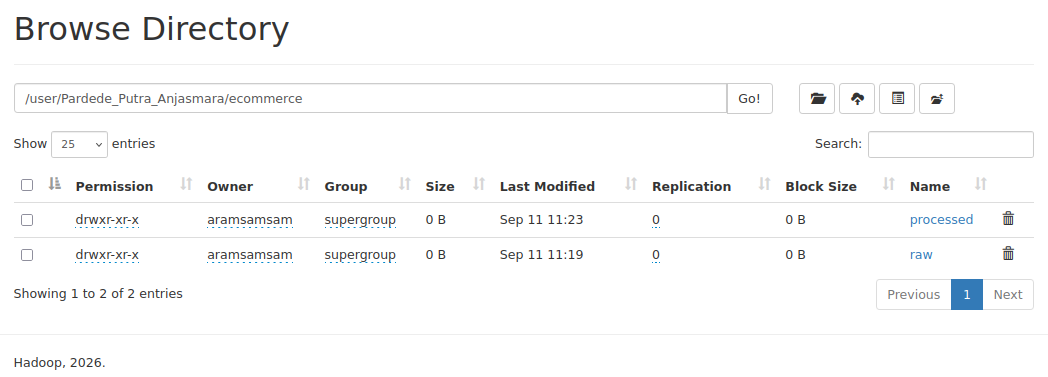

2. Tulisan reflektif (**minimal 100 kata**) pada markdown cell yang menjawab: *Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?*

**Refleksi: Keuntungan Memisahkan Data Mentah (raw) dan Data Olahan (processed) di HDFS**
Memisahkan direktori data mentah (*raw*) dengan data hasil olahan (*processed*) merupakan praktik terbaik (*best practice*) dalam arsitektur Data Lake dan Big Data Engineering.

Keuntungan utamanya adalah **menjaga integritas data awal sebagai *single source of truth***. Data mentah di folder *raw* disimpan secara immutabel (tidak diubah). Apabila terjadi kesalahan logika transformasi pada kode analisis, perubahan kebutuhan bisnis, atau kegagalan pipeline, data engineer dapat melakukan proses ulang (*re-processing*) langsung dari data asli tanpa risiko kehilangan informasi historis.

Selain itu, struktur ini **meningkatkan efisiensi tata kelola data (data governance) dan keamanan**. Tim *Data Analyst* atau *Data Scientist* dapat langsung mengonsumsi data yang sudah dibersihkan pada direktori *processed* untuk kebutuhan pelaporan maupun pemodelan tanpa harus mengulang proses komputasi berat. Pemisahan ini juga memudahkan pengaturan hak akses (*permission control*) serta manajemen siklus hidup (*lifecycle management*) berkas pada sistem terdistribusi.